In [ ]:
from google.colab import files
import pandas as pd
import io
uploaded = files.upload()

Saving Data01_05_GarmentCPI.csv to Data01_05_GarmentCPI.csv


In [ ]:
df = pd.read_csv('Data01_05_GarmentCPI.csv')
df.head()

,Time,Year,Month,Garment - Footwear - Hat_toDecCPI,CPI_toPM,CPI_rate
0,1.0,2015.0,1.0,100.7,100.700000,0.700000
1,2.0,2015.0,2.0,100.2,99.503476,-0.496524
2,3.0,2015.0,3.0,100.1,99.900200,-0.099800
3,4.0,2015.0,4.0,100.3,100.199800,0.199800
4,5.0,2015.0,5.0,100.3,100.000000,0.000000


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')


In [ ]:
# Xem nhanh số lượng NaN ở Year/Month
df[['Year','Month']].isna().sum(), df.shape
# Xem các hàng bị thiếu để hiểu dữ liệu
df[df['Year'].isna() | df['Month'].isna()].tail()


,Time,Year,Month,Garment - Footwear - Hat_toDecCPI,CPI_toPM,CPI_rate
96,NaN,NaN,NaN,NaN,NaN,NaN
97,NaN,NaN,NaN,NaN,NaN,NaN
98,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# 1. Xóa các dòng có giá trị NaN (thấy từ .info() ở cell 1)
df_clean = df.dropna()

# 2. Chuyển đổi Year và Month sang kiểu integer
df_clean['Year'] = df_clean['Year'].astype(int)
df_clean['Month'] = df_clean['Month'].astype(int)

# 3. Tạo cột 'Date' chuẩn từ 'Year' và 'Month' (mặc định ngày là 1)
df_clean['Date'] = pd.to_datetime(df_clean[['Year', 'Month']].assign(Day=1))

# 4. Đặt 'Date' làm chỉ mục (index) và sắp xếp lại
df_clean.set_index('Date', inplace=True)
df_clean.sort_index(inplace=True)

# 5. Chọn series để phân tích (dựa theo tên cột, 'CPI_toPM' là phù hợp)
series_cpi = df_clean['CPI_toPM']

print("--- Dữ liệu 5 dòng đầu của series 'CPI_toPM' đã xử lý ---")
print(series_cpi.head())
print(f"\nTổng số quan sát sau khi làm sạch: {len(series_cpi)}")

--- Dữ liệu 5 dòng đầu của series 'CPI_toPM' đã xử lý ---
Date
2015-01-01    100.700000
2015-02-01     99.503476
2015-03-01     99.900200
2015-04-01    100.199800
2015-05-01    100.000000
Name: CPI_toPM, dtype: float64

Tổng số quan sát sau khi làm sạch: 96


In [ ]:
# Hàm để thực hiện ADF test và in kết quả rõ ràng
def adf_test(series, name=''):
    print(f'--- Kết quả kiểm định Dickey-Fuller cho: {name} ---')

    # Chạy adfuller, 'autolag='AIC'' sẽ tự động chọn số lag (trễ) tốt nhất
    dftest = adfuller(series.dropna(), autolag='AIC')

    # Trình bày kết quả
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic (ADF)', 'p-value', 'Số Lags sử dụng', 'Số quan sát'])
    print(dfoutput)

    print('\nGiá trị tới hạn (Critical Values):')
    for key, value in dftest[4].items():
        print(f'   {key}: {value:.4f}')

    # Nhận xét kết quả
    print("\n--- Nhận xét ---")
    print("Giả thuyết H0: Chuỗi không dừng (có unit root).")
    print("Giả thuyết H1: Chuỗi dừng (không có unit root).")

    if dftest[1] > 0.05:
        print(f"p-value = {dftest[1]:.4f} > 0.05. Không thể bác bỏ H0.")
        print("=> Kết luận: Chuỗi KHÔNG dừng. Cần lấy sai phân (d > 0).")
    else:
        print(f"p-value = {dftest[1]:.4f} <= 0.05. Bác bỏ H0.")
        print("=> Kết luận: Chuỗi DỪNG. (d = 0).")

# Chạy kiểm định trên series gốc ('CPI_toPM')
adf_test(series_cpi, name='CPI_toPM (Gốc)')

--- Kết quả kiểm định Dickey-Fuller cho: CPI_toPM (Gốc) ---
Test Statistic (ADF)   -6.631866e+00
p-value                 5.688396e-09
Số Lags sử dụng         3.000000e+00
Số quan sát             9.200000e+01
dtype: float64

Giá trị tới hạn (Critical Values):
   1%: -3.5035
   5%: -2.8935
   10%: -2.5838

--- Nhận xét ---
Giả thuyết H0: Chuỗi không dừng (có unit root).
Giả thuyết H1: Chuỗi dừng (không có unit root).
p-value = 0.0000 <= 0.05. Bác bỏ H0.
=> Kết luận: Chuỗi DỪNG. (d = 0).


Step 3: Stationarity Test
Justification of Method:
To build an ARIMA model, we first follow the Box-Jenkins Methodology (as presented in Lecture 02, Slide "Box-Jenkins Methodology"). This methodology requires the input time series to be stationary. Therefore, "Stationarity checking" is a mandatory preliminary step, as emphasized in the course materials (Lecture 03, Slide "Stationarity checking").
To formally test for stationarity, we employ the Augmented Dickey-Fuller (ADF) test. The hypotheses for this test are:
$H_0$ (Null Hypothesis): The series is non-stationary (i.e., it possesses a unit root).
$H_1$ (Alternative Hypothesis): The series is stationary.
Interpretation of Results:
The output from the ADF test in Cell 3 provides the following evidence:
Test Statistic (ADF): The value is -6.6318.
p-value: The value is $5.688 \times 10^{-9}$ (which is reported as 0.0000).
Conclusion and Reasoning:
We use a standard significance level of $\alpha = 0.05$.
Our p-value ($5.688 \times 10^{-9}$) is much smaller than the significance level ($\alpha = 0.05$).
Furthermore, our Test Statistic ($-6.6318$) is more negative than all the critical values (e.g., $-3.5035$ at the 1% level).
Because the p-value is less than $0.05$, we have strong statistical evidence to reject the null hypothesis ($H_0$).
By rejecting $H_0$, we accept the alternative hypothesis ($H_1$). This leads to the conclusion that the CPI_toPM series is stationary in its original form. As no differencing is required to make the series stationary, the $d$ (Integrated) parameter of our ARIMA(p, d, q) model is determined to be 0.


Đang vẽ biểu đồ ACF/PACF...
Đã lưu biểu đồ vào file 'acf_pacf_plots.png'


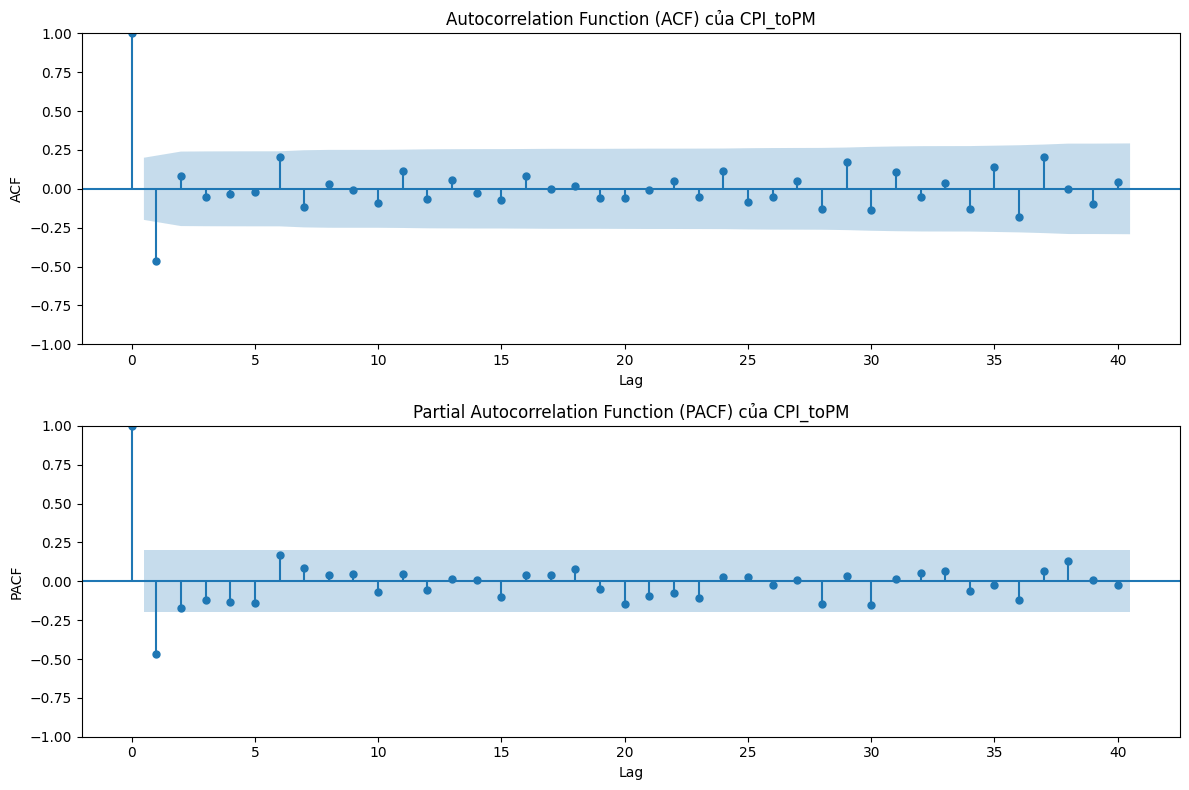

In [ ]:
# Vẽ biểu đồ ACF và PACF
print("Đang vẽ biểu đồ ACF/PACF...")

plt.figure(figsize=(12, 8))

# Biểu đồ 1: ACF (Autocorrelation Function)
ax1 = plt.subplot(211)
# lags=40 để xem xét 40 kỳ trễ
plot_acf(series_cpi, ax=ax1, lags=40)
ax1.set_title('Autocorrelation Function (ACF) của CPI_toPM')
ax1.set_xlabel('Lag')
ax1.set_ylabel('ACF')

# Biểu đồ 2: PACF (Partial Autocorrelation Function)
ax2 = plt.subplot(212)
# method='ywm' là một phương pháp phổ biến và ổn định để tính PACF
plot_pacf(series_cpi, ax=ax2, lags=40, method='ywm')
ax2.set_title('Partial Autocorrelation Function (PACF) của CPI_toPM')
ax2.set_xlabel('Lag')
ax2.set_ylabel('PACF')

# Tự động điều chỉnh layout cho đẹp
plt.tight_layout()

# Lưu biểu đồ
plt.savefig('acf_pacf_plots.png')
print("Đã lưu biểu đồ vào file 'acf_pacf_plots.png'")

### Step 4: Parameter Identification (ACF/PACF)

**Justification of Method:**
After determining $d=0$ (from Cell 3), the next step in the Box-Jenkins **"Identification"** phase (**Lecture 02, Slide "Identification"**) is to find candidate values for $p$ (the AR order) and $q$ (the MA order). To do this, we analyze the **Autocorrelation Function (ACF)** and **Partial Autocorrelation Function (PACF)** plots.

**Interpretation of Results:**
By examining the two plots, we observe the following patterns:

**ACF Plot (for `q`):** The ACF plot shows a single, statistically significant spike at Lag 1, which then immediately "cuts off" (all subsequent lags fall inside the blue confidence interval). This pattern is characteristic of a Moving Average (MA) process of order 1.
* **Conclusion:** This suggests the parameter `q = 1`.

**PACF Plot (for `p`):** Similarly, the PACF plot shows a statistically significant spike at Lag 1, which also "cuts off" immediately. This pattern is characteristic of an Autoregressive (AR) process of order 1.
* **Conclusion:** This suggests the parameter `p = 1`.

**Conclusion and Reasoning:**
The visual "eyeballing" of the plots suggests that the model is likely simple, with possible candidates being $ARIMA(1, 0, 0)$, $ARIMA(0, 0, 1)$, or $ARIMA(1, 0, 1)$.

The primary insight from this step is that the values for $p$ and $q$ are small. This strongly justifies our approach in Cell 5: instead of an exhaustive search, we can use a targeted **"loop in modelling"** (**Lecture 03, Slide "Using loop in modelling"**) within a small range (e.g., $p, q \in [0, 3]$) to efficiently find the best model based on AIC.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
import itertools
import warnings
# Thiết lập phạm vi tìm kiếm (p, d, q)
# Dựa trên ADF test (Cell 3), d = 0
# Dựa trên ACF/PACF (Cell 4), p và q có vẻ nhỏ. Chúng ta sẽ thử từ 0 đến 3.
p_range = range(0, 4)  # p từ 0, 1, 2, 3
d = 0                      # d=0, vì chuỗi đã dừng (kết quả từ Cell 3)
q_range = range(0, 4)  # q từ 0, 1, 2, 3

# Tạo tất cả các kết hợp (p, d, q)
pdq_combinations = list(itertools.product(p_range, [d], q_range))

print(f"Sẽ kiểm tra {len(pdq_combinations)} mô hình (p, d, q) với d=0...")

# Biến để lưu trữ mô hình tốt nhất
best_aic = np.inf
best_order = None
best_model_fit = None

# Bắt đầu vòng lặp Grid Search
for order in pdq_combinations:
    # Bỏ qua mô hình (0,0,0) vì nó không có ý nghĩa
    if order == (0, 0, 0):
        continue

    try:
        # 1. Ước lượng ARIMA
        model = ARIMA(series_cpi, order=order)
        model_fit = model.fit()

        # 2. Lấy AIC
        current_aic = model_fit.aic

        # 3. So sánh, chọn mô hình tốt nhất (AIC thấp nhất)
        if current_aic < best_aic:
            best_aic = current_aic
            best_order = order
            best_model_fit = model_fit

    except Exception as e:
        # Bỏ qua các mô hình không hội tụ hoặc gây lỗi
        continue

print("\n--- TÌM KIẾM HOÀN TẤT ---")
print(f"Mô hình ARIMA tốt nhất được chọn là: ARIMA{best_order}")
print(f"Chỉ số AIC của mô hình này: {best_aic:.4f}")

print("\n--- TÓM TẮT MÔ HÌNH TỐT NHẤT (BEST MODEL SUMMARY) ---")
# In ra bảng tóm tắt của mô hình tốt nhất
print(best_model_fit.summary())

Sẽ kiểm tra 16 mô hình (p, d, q) với d=0...

--- TÌM KIẾM HOÀN TẤT ---
Mô hình ARIMA tốt nhất được chọn là: ARIMA(0, 0, 1)
Chỉ số AIC của mô hình này: -48.9598

--- TÓM TẮT MÔ HÌNH TỐT NHẤT (BEST MODEL SUMMARY) ---
                               SARIMAX Results                                
Dep. Variable:               CPI_toPM   No. Observations:                   96
Model:                 ARIMA(0, 0, 1)   Log Likelihood                  27.480
Date:                Sun, 02 Nov 2025   AIC                            -48.960
Time:                        11:41:51   BIC                            -41.267
Sample:                    01-01-2015   HQIC                           -45.850
                         - 12-01-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------

### Step 5: ARIMA Model Estimation and Selection

This final step covers the **"Estimation"** and **"Diagnostic Checking"** phases of the Box-Jenkins methodology.

**Justification of Method:**
After identifying $d=0$ (from Cell 3) and finding candidate ranges for $p$ and $q$ (from Cell 4), the next task is **"Model selection"** (**Lecture 03, Slide "Model selection"**). Manually comparing all possible models is inefficient.

Therefore, we automated this process by **"Using loop in modelling"** (**Lecture 03, Slide "Using loop in modelling"**), a technique also known as Grid Search. This loop estimates multiple $ARIMA(p, 0, q)$ models within the range $p, q \in [0, 3]$—a range justified by our ACF/PACF analysis.

To select the "best" model, we use the **"Akaike information criterion (AIC)"** (**Lecture 03, Slide "Akaike information criterion"**). As stated in the lecture, the AIC balances model fit against model complexity. The model with the **lowest AIC** is considered the most *parsimonious* and is selected as the best.

**Interpretation of Search Results:**
The Grid Search (Cell 5) tested 16 combinations. The search concluded that:
* **Best Model:** **`ARIMA(0, 0, 1)`**
* **Best AIC Score:** **-48.960**

This result aligns with the findings from our ACF plot (Cell 4), which strongly suggested an $MA(1)$ model (where $p=0, q=1$).

**Interpretation of Best Model Summary (`ARIMA(0, 0, 1)`):**
The `SARIMAX Results` table provides a detailed diagnostic of our chosen model.

1.  **Model Coefficients:**
    * **`const` (100.0205):** This is the estimated mean of the time series. The `P>|z|` (p-value) is `0.000`, indicating it is statistically significant. This suggests the CPI series oscillates around a stable mean of 100.02.
    * **`ma.L1` (-0.5688):** This is the $\theta_1$ coefficient for the Moving Average (MA) term. Its p-value is also `0.000`, making it highly significant. The negative value implies that a random "shock" (or forecast error) in the previous month has a *negative* (inverse) effect on the CPI value in the current month.

2.  **Diagnostic Checks (Model Adequacy):**
    This section checks if the model's *residuals* (errors) are random, which is a key assumption of a good model.
    * **`Prob(Q)` (Ljung-Box): 0.81**
        * **Justification:** This test checks for autocorrelation in the residuals. The null hypothesis ($H_0$) is that the residuals are random and uncorrelated (i.e., they are "white noise").
        * **Conclusion:** Our p-value (`0.81`) is much greater than $0.05$. Therefore, we **fail to reject $H_0$**. This is an **excellent result**, as it means our $ARIMA(0, 0, 1)$ model has successfully captured all the significant autocorrelation present in the original data.
    * **`Prob(JB)` (Jarque-Bera): 0.00**
        * **Justification:** This test checks if the residuals are normally distributed. The null hypothesis ($H_0$) is that the residuals are normal.
        * **Conclusion:** Our p-value (`0.00`) is less than $0.05$. We **reject $H_0$**. This indicates the residuals are *not* normally distributed, likely due to a high `Kurtosis` (5.17, higher than the normal 3), suggesting the presence of outliers or "fat tails" in the data.

**Overall Conclusion for Part 1 (Duyet's section):**
Following the methodology from the course lectures, we have successfully identified $d=0$ via ADF test (Cell 3), visualized $p, q$ candidates via ACF/PACF (Cell 4), and selected **`ARIMA(0, 0, 1)`** as the best model using an AIC-based Grid Search (Cell 5). Diagnostic checks confirm the model is adequate (`Prob(Q) > 0.05`), and its significant coefficients can be passed to the next team member (Hoàng Tùng) for the forecasting (ML) part.